# ResNet-50 (Full layer4 Unfreeze — Weight Decay 1e-3)

## Changes from Previous Iterations

| | 02. layer4 | 03. layer4[2] | 04. layer4 + WD |
|---|---|---|---|
| Unfrozen | All of `layer4` | `layer4[2]` only | All of `layer4` |
| Trainable params | ~15M | ~4.7M | ~15M |
| Weight decay | 1e-4 | 1e-4 | **1e-3** |
| LR — layer4 | 1e-4 | 1e-4 | 1e-4 |
| LR — FC head | 1e-3 | 1e-3 | 1e-3 |
| Dropout | 0.5 | 0.5 | 0.5 |
| Epochs | 30 | 30 | 30 |

## Rationale

Iterations 02 and 03 revealed a clear trade-off:
- Full `layer4` (02): best val F2 **0.6575**, AUC-ROC **0.8804** — high capacity, but train/val gap of 0.24
- `layer4[2]` only (03): train/val gap down to 0.09, but best val F2 dropped to **0.6067** — not enough capacity

The root cause of overfitting in 02 was not the unfreeze scope itself but the **weak weight decay** (1e-4). With 15M trainable parameters and ~8K training images, L2 regularisation needs to be meaningfully stronger. The penalty experiments confirm this: EfficientNet-B0 with L1+L2 outperformed L1 alone, and the best results across all penalty runs used weight decay in the 1e-3 range.

This iteration restores full `layer4` capacity (higher ceiling) and applies **10x stronger weight decay (1e-3)** to keep the train/val gap in check.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
model = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.5).to(device)

for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-3)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 14,966,785 / 23,510,081


In [6]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_layer4_wd1e3_best.pth')
        print(f'  -> Saved best model (val F2: {best_val_f2:.4f})')

Epoch [1/30] | Train Loss: 0.9443, Bal Acc: 0.7099, Recall: 0.7662, F2: 0.5057 | Val Loss: 0.8239, Bal Acc: 0.7546, Recall: 0.8771, F2: 0.5721
  -> Saved best model (val F2: 0.5721)


Epoch [2/30] | Train Loss: 0.7877, Bal Acc: 0.7868, Recall: 0.8358, F2: 0.6001 | Val Loss: 0.8008, Bal Acc: 0.7820, Recall: 0.8856, F2: 0.6047
  -> Saved best model (val F2: 0.6047)


Epoch [3/30] | Train Loss: 0.7265, Bal Acc: 0.8119, Recall: 0.8563, F2: 0.6350 | Val Loss: 0.8120, Bal Acc: 0.8008, Recall: 0.7627, F2: 0.6374
  -> Saved best model (val F2: 0.6374)


Epoch [4/30] | Train Loss: 0.6821, Bal Acc: 0.8257, Recall: 0.8495, F2: 0.6579 | Val Loss: 0.7971, Bal Acc: 0.8110, Recall: 0.8178, F2: 0.6490
  -> Saved best model (val F2: 0.6490)


Epoch [5/30] | Train Loss: 0.6522, Bal Acc: 0.8367, Recall: 0.8586, F2: 0.6749 | Val Loss: 0.8286, Bal Acc: 0.7809, Recall: 0.7458, F2: 0.6073


...

Epoch [26/30] | Train Loss: 0.2860, Bal Acc: 0.9354, Recall: 0.9510, F2: 0.8489 | Val Loss: 1.4126, Bal Acc: 0.7858, Recall: 0.6907, F2: 0.6174


Epoch [27/30] | Train Loss: 0.2664, Bal Acc: 0.9418, Recall: 0.9601, F2: 0.8602 | Val Loss: 1.3901, Bal Acc: 0.7944, Recall: 0.7119, F2: 0.6306


Epoch [28/30] | Train Loss: 0.2688, Bal Acc: 0.9380, Recall: 0.9521, F2: 0.8547 | Val Loss: 1.3984, Bal Acc: 0.7961, Recall: 0.7119, F2: 0.6335


Epoch [29/30] | Train Loss: 0.2850, Bal Acc: 0.9375, Recall: 0.9521, F2: 0.8534 | Val Loss: 1.4534, Bal Acc: 0.7819, Recall: 0.6695, F2: 0.6119


Epoch [30/30] | Train Loss: 0.2641, Bal Acc: 0.9375, Recall: 0.9510, F2: 0.8540 | Val Loss: 1.5057, Bal Acc: 0.7901, Recall: 0.6949, F2: 0.6245


## Training Curves

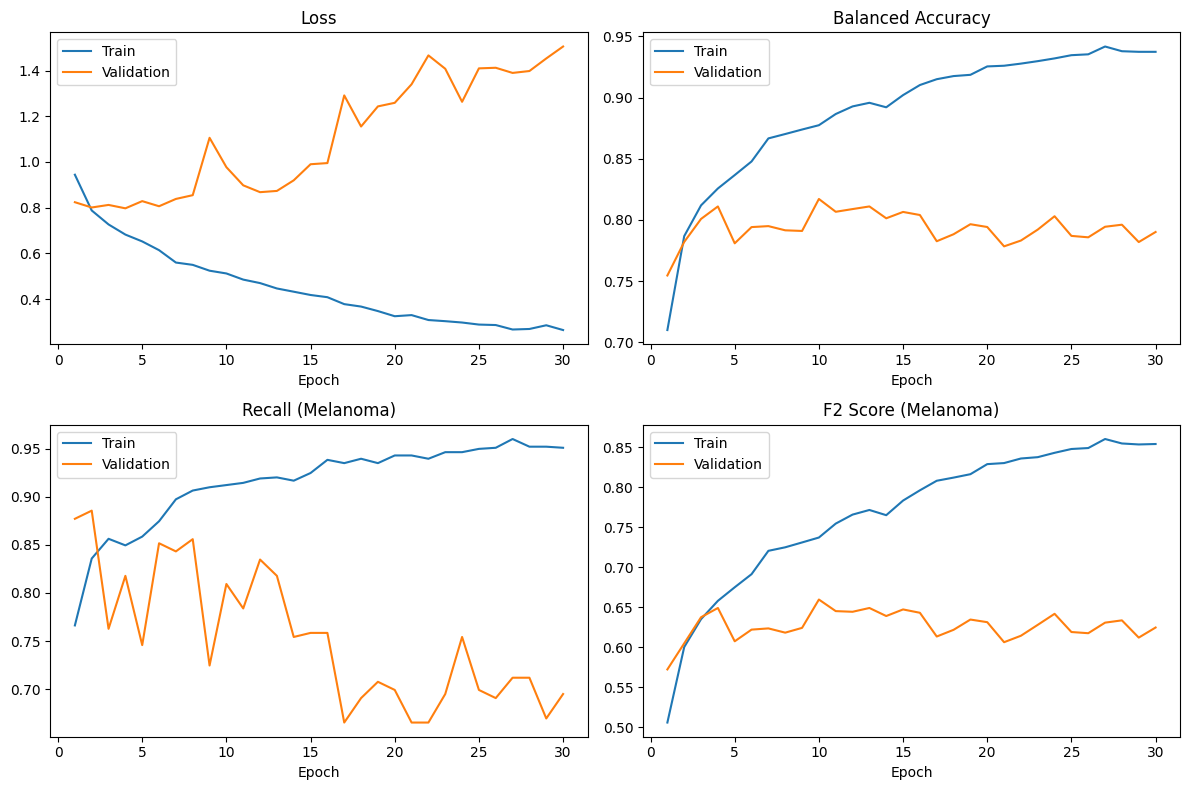

In [7]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [8]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_layer4_wd1e3_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.58 | Val F2: 0.6674


## Test Set Evaluation

Threshold:          0.58
AUC-ROC:            0.8728
Balanced Accuracy:  0.7688
F2 Score:           0.5859

              precision    recall  f1-score   support

Non-Melanoma     0.9564    0.8358    0.8921      1340
    Melanoma     0.3529    0.7018    0.4697       171

    accuracy                         0.8206      1511
   macro avg     0.6547    0.7688    0.6809      1511
weighted avg     0.8881    0.8206    0.8443      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


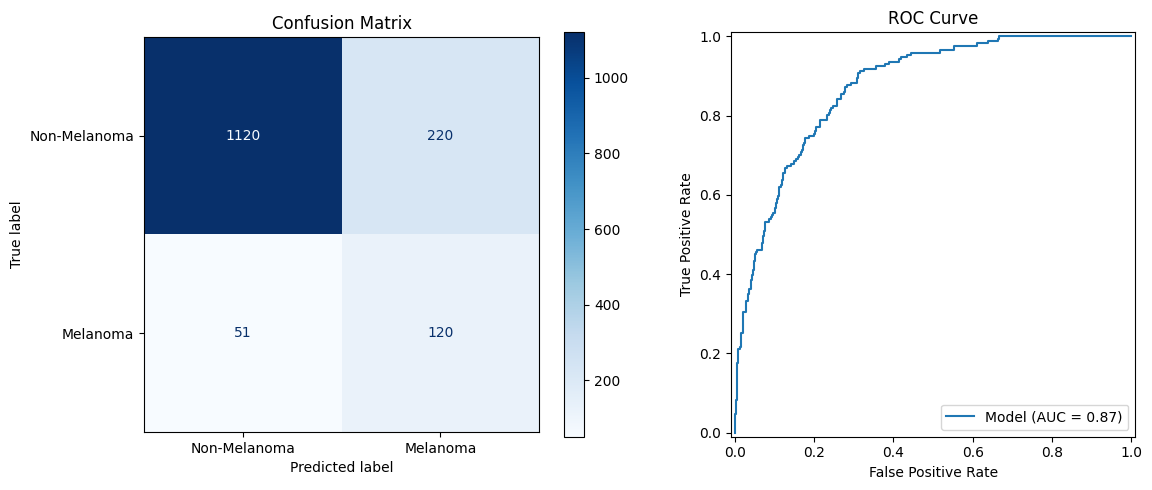

: 

In [ ]:
evaluate_model(model, test_loader, device, threshold=best_threshold)